In [ ]:
import numpy as np
import pickle
from numba import cuda
from time import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


# -------------------------------
# Utility functions for convolution (CPU)
# -------------------------------

def im2col(x, kernel_h, kernel_w, stride, pad):
    N, C, H, W = x.shape
    out_h = (H + 2*pad - kernel_h) // stride + 1
    out_w = (W + 2*pad - kernel_w) // stride + 1
    if pad > 0:
        x_pad = np.pad(x, ((0,0), (0,0), (pad,pad), (pad,pad)), mode='constant')
    else:
        x_pad = x
    cols = np.zeros((N, C, kernel_h, kernel_w, out_h, out_w))
    for n in range(N):
        for c in range(C):
            for kh in range(kernel_h):
                for kw in range(kernel_w):
                    h_start = kh
                    h_end = h_start + stride * out_h
                    w_start = kw
                    w_end = w_start + stride * out_w
                    cols[n, c, kh, kw, :, :] = x_pad[n, c, h_start:h_end:stride, w_start:w_end:stride]
    cols = cols.transpose(0,4,5,1,2,3).reshape(N*out_h*out_w, -1)
    return cols, out_h, out_w

def col2im(cols, x_shape, kernel_h, kernel_w, stride, pad):
    N, C, H, W = x_shape
    out_h = (H + 2*pad - kernel_h) // stride + 1
    out_w = (W + 2*pad - kernel_w) // stride + 1
    x_pad = np.zeros((N, C, H + 2*pad, W + 2*pad))
    cols = cols.reshape(N, out_h, out_w, C, kernel_h, kernel_w).transpose(0,3,4,5,1,2)
    for n in range(N):
        for c in range(C):
            for kh in range(kernel_h):
                for kw in range(kernel_w):
                    h_start = kh
                    h_end = h_start + stride * out_h
                    w_start = kw
                    w_end = w_start + stride * out_w
                    x_pad[n, c, h_start:h_end:stride, w_start:w_end:stride] += cols[n, c, kh, kw, :, :]
    if pad > 0:
        return x_pad[:, :, pad:-pad, pad:-pad]
    else:
        return x_pad

# -------------------------------
# GPU kernels (flattened 1D indexing)
# -------------------------------

@cuda.jit
def conv2d_forward_kernel(x, w, b, out, stride, pad):
    """
    x: (N, C, H, W)
    w: (F, C, KH, KW)
    b: (F,)
    out: (N, F, outH, outW)   -- flattened in launch
    """
    idx = cuda.grid(1)
    if idx < out.size:
        # Compute 4D coordinates from flattened index
        N, F, outH, outW = out.shape
        ow = idx % outW
        oh = (idx // outW) % outH
        f = (idx // (outW * outH)) % F
        n = idx // (outW * outH * F)
        
        C, KH, KW = w.shape[1], w.shape[2], w.shape[3]
        H, W = x.shape[2], x.shape[3]
        ih_start = oh * stride - pad
        iw_start = ow * stride - pad
        acc = 0.0
        for c in range(C):
            for kh in range(KH):
                for kw in range(KW):
                    ih = ih_start + kh
                    iw = iw_start + kw
                    if 0 <= ih < H and 0 <= iw < W:
                        acc += x[n, c, ih, iw] * w[f, c, kh, kw]
        out[n, f, oh, ow] = acc + b[f]

@cuda.jit
def conv2d_backward_input_kernel(dout, w, dx, stride, pad):
    """
    dout: (N, F, outH, outW)
    w:    (F, C, KH, KW)
    dx:   (N, C, H, W)   -- flattened
    """
    idx = cuda.grid(1)
    if idx < dx.size:
        N, C, H, W = dx.shape
        iw = idx % W
        ih = (idx // W) % H
        c = (idx // (W * H)) % C
        n = idx // (W * H * C)
        
        F, KH, KW = w.shape[0], w.shape[2], w.shape[3]
        outH = dout.shape[2]
        outW = dout.shape[3]
        grad = 0.0
        for f in range(F):
            for kh in range(KH):
                for kw in range(KW):
                    oh = (ih + pad - kh) // stride
                    ow = (iw + pad - kw) // stride
                    if (ih + pad - kh) % stride == 0 and (iw + pad - kw) % stride == 0:
                        if 0 <= oh < outH and 0 <= ow < outW:
                            grad += dout[n, f, oh, ow] * w[f, c, kh, kw]
        dx[n, c, ih, iw] = grad

@cuda.jit
def conv2d_backward_weight_kernel(dout, x, dw, stride, pad):
    """
    dout: (N, F, outH, outW)
    x:    (N, C, H, W)
    dw:   (F, C, KH, KW)   -- flattened
    """
    idx = cuda.grid(1)
    if idx < dw.size:
        F, C, KH, KW = dw.shape
        kw = idx % KW
        kh = (idx // KW) % KH
        c = (idx // (KW * KH)) % C
        f = idx // (KW * KH * C)
        
        N = dout.shape[0]
        outH = dout.shape[2]
        outW = dout.shape[3]
        grad = 0.0
        for n in range(N):
            for oh in range(outH):
                for ow in range(outW):
                    ih = oh * stride + kh - pad
                    iw = ow * stride + kw - pad
                    if 0 <= ih < x.shape[2] and 0 <= iw < x.shape[3]:
                        grad += dout[n, f, oh, ow] * x[n, c, ih, iw]
        dw[f, c, kh, kw] = grad

# -------------------------------
# Base Layer
# -------------------------------

class Layer:
    def forward(self, x):
        raise NotImplementedError
    def backward(self, dout):
        raise NotImplementedError
    def update(self, lr):
        pass

# -------------------------------
# Convolutional Layer (fixed GPU)
# -------------------------------

class Conv2D(Layer):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, use_gpu=False):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size if isinstance(kernel_size, tuple) else (kernel_size, kernel_size)
        self.stride = stride
        self.padding = padding
        self.use_gpu = use_gpu and cuda.is_available()
        
        # He initialization
        self.W = np.random.randn(out_channels, in_channels, self.kernel_size[0], self.kernel_size[1]) * np.sqrt(2.0 / (in_channels * self.kernel_size[0] * self.kernel_size[1]))
        self.b = np.zeros(out_channels)
        self.dW = None
        self.db = None
        self.x = None
        self.cache = None

    def forward(self, x):
        self.x = x
        N, C, H, W = x.shape
        KH, KW = self.kernel_size
        out_h = (H + 2*self.padding - KH) // self.stride + 1
        out_w = (W + 2*self.padding - KW) // self.stride + 1
        
        if self.use_gpu:
            # GPU forward with 1D grid
            d_x = cuda.to_device(x.astype(np.float32))
            d_W = cuda.to_device(self.W.astype(np.float32))
            d_b = cuda.to_device(self.b.astype(np.float32))
            out = np.zeros((N, self.out_channels, out_h, out_w), dtype=np.float32)
            d_out = cuda.to_device(out)
            total_elements = N * self.out_channels * out_h * out_w
            threadsperblock = 256
            blockspergrid = (total_elements + threadsperblock - 1) // threadsperblock
            conv2d_forward_kernel[blockspergrid, threadsperblock](d_x, d_W, d_b, d_out, self.stride, self.padding)
            out = d_out.copy_to_host()
            # Keep device input for backward pass
            self.cache = (d_x, d_W)   # d_x is input on device, d_W needed? We'll recompute or keep.
            return out
        else:
            # CPU forward
            col, out_h, out_w = im2col(x, KH, KW, self.stride, self.padding)
            W_col = self.W.reshape(self.out_channels, -1)
            out_col = np.dot(col, W_col.T) + self.b
            out = out_col.reshape(N, out_h, out_w, self.out_channels).transpose(0, 3, 1, 2)
            self.cache = (col, out_h, out_w)
            return out

    def backward(self, dout):
        N, _, out_h, out_w = dout.shape
        _, C, H, W = self.x.shape
        KH, KW = self.kernel_size
        
        if self.use_gpu:
            # GPU backward
            d_dout = cuda.to_device(dout.astype(np.float32))
            d_W = cuda.to_device(self.W.astype(np.float32))
            d_x = self.cache[0]  # device input from forward
            
            # dx
            dx = np.zeros((N, C, H, W), dtype=np.float32)
            d_dx = cuda.to_device(dx)
            total_input = N * C * H * W
            threads = 256
            blocks_in = (total_input + threads - 1) // threads
            conv2d_backward_input_kernel[blocks_in, threads](d_dout, d_W, d_dx, self.stride, self.padding)
            dx = d_dx.copy_to_host()
            
            # dW
            d_dW = cuda.device_array(self.W.shape, dtype=np.float32)
            total_weights = self.W.size
            blocks_w = (total_weights + threads - 1) // threads
            conv2d_backward_weight_kernel[blocks_w, threads](d_dout, d_x, d_dW, self.stride, self.padding)
            self.dW = d_dW.copy_to_host()
            
            # db
            self.db = np.sum(dout, axis=(0,2,3))
            return dx
        else:
            # CPU backward
            dout_reshaped = dout.transpose(0, 2, 3, 1).reshape(-1, self.out_channels)
            dcol = np.dot(dout_reshaped, self.W.reshape(self.out_channels, -1))
            dx = col2im(dcol, self.x.shape, KH, KW, self.stride, self.padding)
            col, _, _ = self.cache
            self.dW = np.dot(dout_reshaped.T, col).reshape(self.W.shape)
            self.db = np.sum(dout_reshaped, axis=0)
            return dx

    def update(self, lr):
        self.W -= lr * self.dW
        self.b -= lr * self.db

# -------------------------------
# MaxPool2D (unchanged, works on CPU)
# -------------------------------

class MaxPool2D(Layer):
    def __init__(self, pool_size=2, stride=2, use_gpu=False):
        self.pool_size = pool_size if isinstance(pool_size, tuple) else (pool_size, pool_size)
        self.stride = stride
        self.use_gpu = use_gpu
        self.cache = None

    def forward(self, x):
        N, C, H, W = x.shape
        PH, PW = self.pool_size
        out_h = (H - PH) // self.stride + 1
        out_w = (W - PW) // self.stride + 1
        out = np.zeros((N, C, out_h, out_w), dtype=x.dtype)
        max_pos = np.zeros((N, C, out_h, out_w, 2), dtype=np.int32)
        for n in range(N):
            for c in range(C):
                for i in range(out_h):
                    for j in range(out_w):
                        h_start = i * self.stride
                        h_end = h_start + PH
                        w_start = j * self.stride
                        w_end = w_start + PW
                        patch = x[n, c, h_start:h_end, w_start:w_end]
                        max_val = np.max(patch)
                        out[n, c, i, j] = max_val
                        pos = np.unravel_index(np.argmax(patch), patch.shape)
                        max_pos[n, c, i, j] = [h_start + pos[0], w_start + pos[1]]
        self.cache = (x.shape, max_pos)
        return out

    def backward(self, dout):
        N, C, H, W = self.cache[0]
        PH, PW = self.pool_size
        max_pos = self.cache[1]
        dx = np.zeros((N, C, H, W), dtype=dout.dtype)
        for n in range(N):
            for c in range(C):
                for i in range(dout.shape[2]):
                    for j in range(dout.shape[3]):
                        h, w = max_pos[n, c, i, j]
                        dx[n, c, h, w] += dout[n, c, i, j]
        return dx

# -------------------------------
# Flatten, Dense, Activations, Loss (unchanged)
# -------------------------------

class Flatten(Layer):
    def forward(self, x):
        self.original_shape = x.shape
        return x.reshape(x.shape[0], -1)
    def backward(self, dout):
        return dout.reshape(self.original_shape)

class Dense(Layer):
    def __init__(self, in_features, out_features):
        self.W = np.random.randn(in_features, out_features) * np.sqrt(2.0 / in_features)
        self.b = np.zeros(out_features)
        self.x = None
        self.dW = None
        self.db = None
    def forward(self, x):
        self.x = x
        return np.dot(x, self.W) + self.b
    def backward(self, dout):
        dx = np.dot(dout, self.W.T)
        self.dW = np.dot(self.x.T, dout)
        self.db = np.sum(dout, axis=0)
        return dx
    def update(self, lr):
        self.W -= lr * self.dW
        self.b -= lr * self.db

class ReLU(Layer):
    def forward(self, x):
        self.cache = x
        return np.maximum(0, x)
    def backward(self, dout):
        dx = dout.copy()
        dx[self.cache <= 0] = 0
        return dx

class Sigmoid(Layer):
    def forward(self, x):
        self.out = 1 / (1 + np.exp(-x))
        return self.out
    def backward(self, dout):
        return dout * self.out * (1 - self.out)

class BinaryCrossEntropyLoss:
    def forward(self, y_pred, y_true):
        eps = 1e-12
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    def backward(self, y_pred, y_true):
        eps = 1e-12
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return (y_pred - y_true) / (y_pred * (1 - y_pred) + eps) / y_pred.shape[0]

# -------------------------------
# Model class (unchanged except minor fix in _get_grads)
# -------------------------------

class Model:
    def __init__(self, use_gpu=False):
        self.layers = []
        self.use_gpu = use_gpu and cuda.is_available()

    def add(self, layer):
        self.layers.append(layer)

    def predict(self, X):
        y = X
        cache = []
        for layer in self.layers:
            y = layer.forward(y)
            cache.append(y)
        return y, cache

    def _get_grads(self, dL_dy, cache):
        dy = dL_dy
        grads = []
        for layer in reversed(self.layers):
            dy = layer.backward(dy)
            grads.append(None)  # gradients stored inside layers
        return grads

    def _update_weights(self, lr):
        for layer in self.layers:
            if hasattr(layer, 'update'):
                layer.update(lr)

    def train_on_batch(self, X, y, lr=0.001):
        out, cache = self.predict(X)
        loss_fn = BinaryCrossEntropyLoss()
        loss = loss_fn.forward(out, y)
        dout = loss_fn.backward(out, y)
        self._get_grads(dout, cache)
        self._update_weights(lr)
        return loss

    def save_model(self, path):
        model_data = []
        for layer in self.layers:
            if hasattr(layer, 'W') and hasattr(layer, 'b'):
                model_data.append((layer.W, layer.b))
            else:
                model_data.append(None)
        with open(path, 'wb') as f:
            pickle.dump(model_data, f)

    @classmethod
    def from_file(cls, path, use_gpu=False):
        model = cls(use_gpu)
        with open(path, 'rb') as f:
            model_data = pickle.load(f)
        raise NotImplementedError("Please build architecture manually then load weights with load_weights method")
    
    def load_weights(self, path):
        with open(path, 'rb') as f:
            model_data = pickle.load(f)
        for layer, data in zip(self.layers, model_data):
            if data is not None:
                layer.W, layer.b = data


In [8]:
def generate_class_images(classes=10, pictures_per_class=200, length=256,
                          similarity=0.1, func_type='trigonometric',
                          amplitude=1.0, exponent=1.0, noise_level=0.0,
                          seed=None, func_kwargs=None):
    """
    Генерирует синтетические изображения на основе параметрической функции.
    func_type: 'polynomial', 'trigonometric', 'radial', 'spiral'
    """
    if seed is not None:
        np.random.seed(seed)

    n_samples = classes * pictures_per_class
    H = W = length

    # Количество параметров для каждого типа
    if func_type == 'polynomial':
        n_params = 6
    elif func_type == 'trigonometric':
        n_params = 8
    elif func_type == 'radial':
        n_params = 5
    elif func_type == 'spiral':
        n_params = 6
    else:
        raise ValueError("Unknown func_type")

    # Генерация центров классов
    centers = np.random.randn(classes, n_params)
    centroid = centers.mean(axis=0, keepdims=True)
    centers_centered = centers - centroid
    mean_dist = np.mean(np.linalg.norm(centers_centered, axis=1))
    if mean_dist > 0:
        scale = similarity / mean_dist
        centers_scaled = centroid + centers_centered * scale
    else:
        centers_scaled = centers.copy()

    x = np.arange(H)
    y = np.arange(W)
    xx, yy = np.meshgrid(x, y, indexing='ij')

    X_list, y_list = [], []
    intra_class_noise = similarity * 0.2

    for cls in range(classes):
        center = centers_scaled[cls]
        for _ in range(pictures_per_class):
            params = center + np.random.randn(n_params) * intra_class_noise

            if func_type == 'polynomial':
                a, b, c, d, e, f = params
                Z = (a * xx**2 + b * yy**2 + c * xx*yy +
                     d * xx + e * yy + f)
            elif func_type == 'trigonometric':
                A1, A2, B1, B2, C1, C2, D, E = params
                Z = (A1 * np.sin(2*np.pi*xx/length * B1) +
                     A2 * np.cos(2*np.pi*yy/length * B2) +
                     C1 * np.sin(2*np.pi*(xx+yy)/length * C2) +
                     D * xx/length + E * yy/length)
            elif func_type == 'radial':
                cx, cy, sigma, amp, offset = params
                r2 = (xx - cx)**2 + (yy - cy)**2
                Z = amp * np.exp(-r2 / (2*sigma**2)) + offset
            elif func_type == 'spiral':
                a, b, omega, phi, amp, offset = params
                r = np.sqrt(xx**2 + yy**2)
                theta = np.arctan2(yy, xx)
                spiral = a + b * theta
                Z = amp * np.sin(omega * (r - spiral) + phi) + offset
            else:
                raise ValueError

            Z = Z * amplitude
            if exponent != 1.0:
                Z = np.sign(Z) * (np.abs(Z) ** exponent)

            Z_min, Z_max = Z.min(), Z.max()
            if Z_max > Z_min:
                Z_norm = (Z - Z_min) / (Z_max - Z_min) * 255
            else:
                Z_norm = np.zeros_like(Z)

            if noise_level > 0:
                noise = np.random.randn(H, W) * (noise_level * 255)
                Z_norm = np.clip(Z_norm + noise, 0, 255)

            img = Z_norm.astype(np.uint8).reshape(1, H, W)
            X_list.append(img)
            y_list.append(cls)

    X = np.stack(X_list, axis=0)
    y = np.array(y_list)

    indices = np.random.permutation(n_samples)
    X = X[indices]
    y = y[indices]

    return X, y

In [16]:
def predict_classification(model, X, task='multiclass', threshold=0.5, return_probs=False):
    """
    Выполняет предсказание классов (и вероятностей) для входных данных.
    
    Параметры:
    ----------
    model : Model
        Обученная модель (из вашей реализации).
    X : np.ndarray
        Входные данные (n_samples, channels, H, W) или (n_samples, features).
    task : str
        Тип задачи: 'binary' или 'multiclass'.
    threshold : float
        Порог для бинарной классификации.
    return_probs : bool
        Если True, возвращает также вероятности классов.
    
    Возвращает:
    -----------
    pred_classes : np.ndarray
        Предсказанные классы.
    (pred_classes, probs) : если return_probs=True
    """
    # model.predict возвращает (output, cache) – берём только output
    logits, _ = model.predict(X)
    
    if task == 'binary':
        probs = 1 / (1 + np.exp(-logits))   # sigmoid
        pred_classes = (probs >= threshold).astype(int).flatten()
        if return_probs:
            return pred_classes, probs.flatten()
        return pred_classes
    elif task == 'multiclass':
        # Стабильный softmax для логитов
        shifted = logits - np.max(logits, axis=1, keepdims=True)
        exp_logits = np.exp(shifted)
        probs = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
        pred_classes = np.argmax(probs, axis=1)
        if return_probs:
            return pred_classes, probs
        return pred_classes
    else:
        raise ValueError("task должен быть 'binary' или 'multiclass'")

def classification_metrics(y_true, y_pred, task='multiclass', average='macro'):
    """
    Вычисляет метрики классификации по истинным и предсказанным меткам.
    
    Параметры:
    ----------
    y_true : np.ndarray
        Истинные метки классов (n_samples,).
    y_pred : np.ndarray
        Предсказанные метки классов (n_samples,).
    task : str
        Тип задачи: 'binary' или 'multiclass'. Влияет на способ вычисления метрик.
    average : str
        Для многоклассовой классификации: 'macro', 'micro', 'weighted' или None.
        По умолчанию 'macro'. Используется только если доступен scikit-learn.
    
    Возвращает:
    -----------
    dict : словарь с ключами:
        - 'accuracy': accuracy
        - 'precision': precision
        - 'recall': recall
        - 'f1': f1-score
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if y_true.ndim > 1:
        y_true = y_true.flatten()
    if y_pred.ndim > 1:
        y_pred = y_pred.flatten()
    
    # Accuracy
    accuracy = np.mean(y_true == y_pred)
    
    # Если есть sklearn, используем его для precision/recall/f1
    try:
        from sklearn.metrics import precision_score, recall_score, f1_score
        precision = precision_score(y_true, y_pred, average=average, zero_division=0)
        recall = recall_score(y_true, y_pred, average=average, zero_division=0)
        f1 = f1_score(y_true, y_pred, average=average, zero_division=0)
    except ImportError:
        # Ручной расчёт для бинарной классификации
        if task == 'binary':
            tp = np.sum((y_pred == 1) & (y_true == 1))
            fp = np.sum((y_pred == 1) & (y_true == 0))
            fn = np.sum((y_pred == 0) & (y_true == 1))
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        else:
            # Для многоклассовой без sklearn возвращаем None, но предупреждаем
            print("Для многоклассовой классификации установите библиотеку scikit-learn")
            precision = recall = f1 = None
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [9]:
seed = 42
classes=5
length = 32
dims=2
examples_per_class = 2
X_, y_ = generate_class_images(
    classes=classes,
    pictures_per_class=200,
    length=length,          # для быстрого теста 32x32 (ваша CNN ожидает 32x32)
    similarity=0.5,
    func_type='trigonometric',
    amplitude=5.0, 
    exponent=0.01,
    noise_level=0.15,
    seed=42
)

print("X_.shape:", X_.shape)   # (2000, 1, 32, 32)
print("y_.shape:", y_.shape)   # (2000,)

X_.shape: (1000, 1, 32, 32)
y_.shape: (1000,)


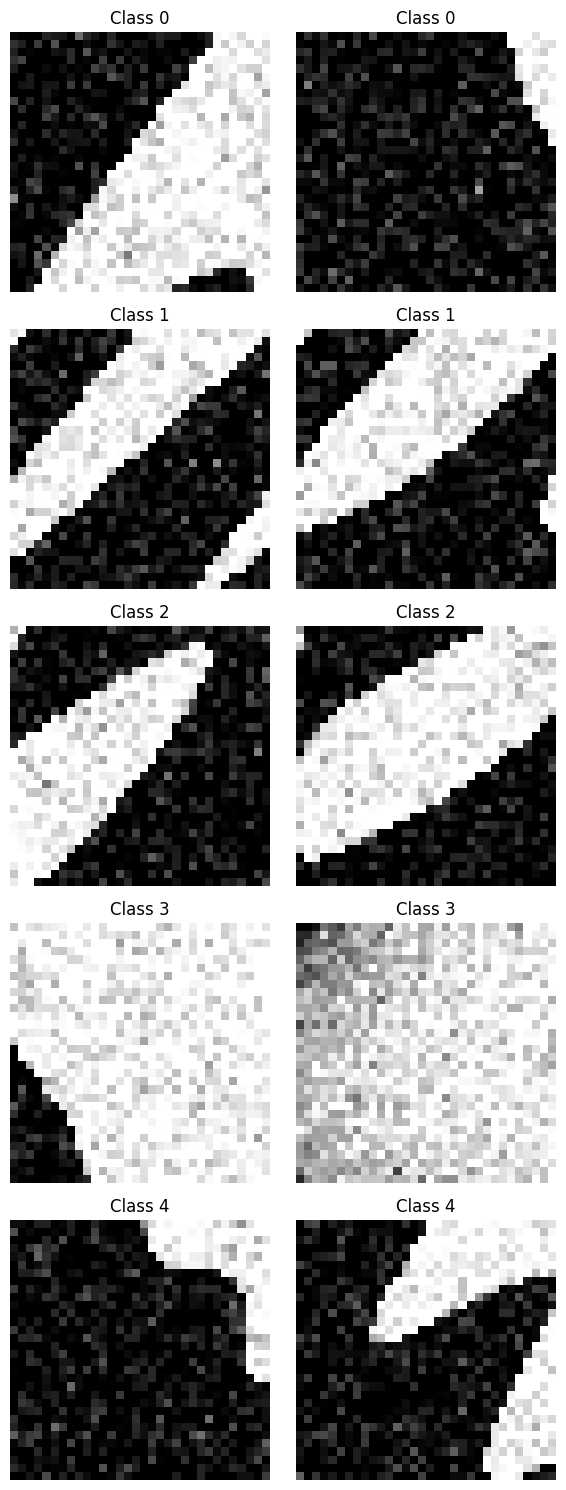

In [10]:
fig, axes = plt.subplots(classes, examples_per_class, figsize=(6, 15))
if classes == 1:
    axes = axes.reshape(1, -1)

for cls in range(classes):
    # Найти индексы всех изображений этого класса
    indices = np.where(y_ == cls)[0]
    # Выбрать первые `examples_per_class` (можно случайные)
    chosen = indices[:examples_per_class]
    
    for ex, idx in enumerate(chosen):
        ax = axes[cls, ex]
        img = X_[idx, 0]   # убираем ось канала
        ax.imshow(img, cmap='gray', vmin=0, vmax=255)
        ax.set_title(f'Class {cls}')
        ax.axis('off')

plt.tight_layout()
plt.show()

In [11]:
# Функции потерь с защитой от неверной размерности
def mse(pred, true):
    # Приводим true к той же размерности, что и pred
    if true.ndim == 1:
        true = true.reshape(-1, 1)
    return np.mean((pred - true) ** 2), 2 * (pred - true) / len(pred)

def softmax_cross_entropy(y_pred, y_onehot):
    # y_pred — логиты (batch, classes)
    shifted = y_pred - np.max(y_pred, axis=1, keepdims=True)
    exp_logits = np.exp(shifted)
    probs = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
    loss = -np.mean(np.sum(y_onehot * np.log(probs + 1e-15), axis=1))
    dlogits = (probs - y_onehot) / y_pred.shape[0]
    return loss, dlogits

In [ ]:
# Построение модели (без явного Softmax)
def build_model(input_channels, img_size, classes, base_filters=16, use_gpu=False):
    """
    Строит CNN с 4 свёрточными блоками. Выходной слой – линейный (логиты).
    """
    model = Model(use_gpu=use_gpu)
    final_size = img_size // 16   # 4 пулинга
    
    # Блок 1
    model.add(Conv2D(input_channels, base_filters, kernel_size=3, padding=1, use_gpu=model.use_gpu))
    model.add(ReLU())
    model.add(MaxPool2D(pool_size=2, stride=2))
    
    # Блок 2
    model.add(Conv2D(base_filters, base_filters, kernel_size=3, padding=1, use_gpu=model.use_gpu))
    model.add(ReLU())
    model.add(MaxPool2D(pool_size=2, stride=2))

    # Блок 3
    model.add(Conv2D(base_filters, 2*base_filters, kernel_size=3, padding=1, use_gpu=model.use_gpu))
    model.add(ReLU())
    model.add(MaxPool2D(pool_size=2, stride=2))
    
    # Блок 4
    model.add(Conv2D(2*base_filters, 2*base_filters, kernel_size=3, padding=1, use_gpu=model.use_gpu))
    model.add(ReLU())
    model.add(MaxPool2D(pool_size=2, stride=2))
    
    model.add(Flatten())
    model.add(Dense(2*base_filters * final_size * final_size, 128))
    model.add(ReLU())
    model.add(Dense(128, classes))   
    return model


# Подготовка данных (как ранее)
X_train, X_test_parent, y_train, y_test_parent = train_test_split(
    X_, y_, test_size=0.4, random_state=seed)

X_test, X_val, y_test, y_val = train_test_split(
    X_test_parent, y_test_parent, test_size=0.4, random_state=seed)

X_train_norm = X_train.astype(np.float32) / 255.0
X_val_norm = X_val.astype(np.float32) / 255.0
X_test_norm = X_test.astype(np.float32) / 255.0

y_train_onehot = np.eye(classes)[y_train.flatten()]
y_val_onehot = np.eye(classes)[y_val.flatten()]

img_size = X_train_norm.shape[2] 
input_channels = X_train_norm.shape[1]

model = build_model(input_channels=input_channels,
                    img_size=img_size,
                    classes=classes,
                    base_filters=32,
                    use_gpu=True)       # или False

# Цикл обучения
hist = []
best_val_loss = float('inf')
patience = 10
no_improve = 0
lr = 0.01
batch_size = 256

ts = time()
for epoch in range(10000):
    # Перемешивание и батчи
    perm = np.random.permutation(len(X_train_norm))
    for i in range(0, len(X_train_norm), batch_size):
        idx = perm[i:i+batch_size]
        X_batch = X_train_norm[idx]
        y_batch = y_train_onehot[idx]
        y_pred, _ = model.predict(X_batch)       # логиты
        loss, dout = softmax_cross_entropy(y_pred, y_batch)
        model._get_grads(dout, None)
        model._update_weights(lr)
    
    # Валидация
    y_pred_val, _ = model.predict(X_val_norm)
    val_loss, _ = softmax_cross_entropy(y_pred_val, y_val_onehot)
    
    hist.append((loss, val_loss))
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch}")
            break
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch}, loss: {loss:.6f}, val_loss: {val_loss:.6f}')

total_time = time() - ts
total_epochs = len(hist)
avg_time_per_epoch = total_time / total_epochs if total_epochs > 0 else 0

print(f"Training time: {total_time:.2f} sec")
print(f"Total epochs: {total_epochs}")
print(f"Average time per epoch: {avg_time_per_epoch:.4f} sec")
hist = np.array(hist)

# Тестирование
y_pred_test, _ = model.predict(X_test_norm)
test_loss, _ = softmax_cross_entropy(y_pred_test, np.eye(classes)[y_test.flatten()])
test_acc = np.mean(np.argmax(y_pred_test, axis=1) == y_test.flatten())
print(f"Test loss: {test_loss:.4f}, Test accuracy: {test_acc:.4f}")

/home/leous/project/2_course/.venv/lib/python3.11/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 72 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/leous/project/2_course/.venv/lib/python3.11/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 36 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/leous/project/2_course/.venv/lib/python3.11/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 2 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


Epoch 0, loss: 2.520533, val_loss: 2.195409
Epoch 10, loss: 0.541356, val_loss: 0.603729
Epoch 20, loss: 0.375202, val_loss: 0.508057
Epoch 30, loss: 0.495214, val_loss: 0.760927
Epoch 40, loss: 0.320260, val_loss: 0.447093
Epoch 50, loss: 0.353259, val_loss: 0.485038
Early stopping at epoch 54
Training time: 4042.88 sec
Total epochs: 55
Average time per epoch: 73.5068 sec
Test loss: 0.4543, Test accuracy: 0.8167


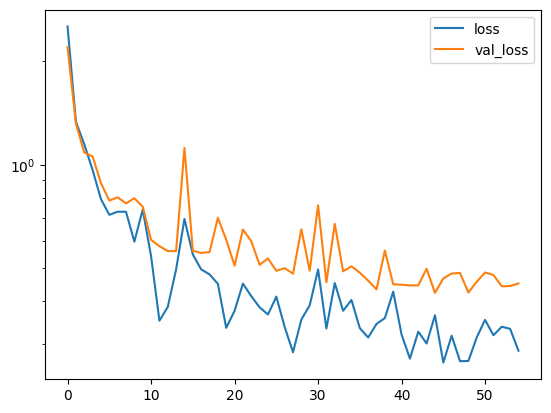

In [13]:
# X_test, y_test = X_test_parent, y_test_parent
# X_test_norm = scaler.transform(X_test)     

plt.yscale('log')
plt.plot(hist[:, 0], label="loss")
plt.plot(hist[:, 1], label="val_loss")
plt.legend()

In [17]:
predicts = predict_classification(model, X_test_norm, task='multiclass')

metrics = classification_metrics(y_test, predicts, task='multiclass')
print(metrics)

{'accuracy': 0.8166666666666667, 'precision': 0.8278550495467003, 'recall': 0.8281568993494688, 'f1': 0.8138866980972244}
